# First plotting attempt of example data

In [1]:
#import packages
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import inspect
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point

In [2]:
# Function to remove suffix from node names
def remove_suffix(node):
    return node.split('_')[0] + '_' + node.split('_')[1]

def plot_large_network(nodes, edges, edge_types, edge_capacities, edge_coordinates, figsize=None, dpi=None,save_fig=None):
    # Create a graph
    G = nx.Graph()

    # Add nodes to the graph
    G.add_nodes_from(nodes)

    # Add edges to the graph with edge types and capacities as attributes
    for edge, edge_type, capacity in zip(edges, edge_types, edge_capacities):
        G.add_edge(edge[0], edge[1], edge_type=edge_type, capacity=capacity)

    # Get positions for the nodes based on Web Mercator coordinates
    pos = {node: tuple(map(float, edge_coordinates[node][1:-1].split(', '))) for node in G.nodes()}

    # Normalize edge capacities to have a maximum thickness of 1
    max_capacity = max(edge_capacities)
    normalized_edge_widths = [1.5 * capacity / max_capacity for capacity in edge_capacities]

    # Define colors for different edge types
    edge_colors = {
        'existing': 'black',
        'new': 'blue',
        'converted': 'green',
        # Add more types and colors as needed
    }

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=0)

    # Draw edges with labels for edge types and capacities
    for (u, v), width, edge_type in zip(G.edges(), normalized_edge_widths, edge_types):
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=width, edge_color=edge_colors[edge_type])
    
    # Add legend for selected edge thicknesses and capacity
    selected_widths = [0.1, 0.5, 1.0]  # Adjust these values based on your preferences
    rounded_widths = [int(max_capacity * width) for width in selected_widths]
    legend_labels_thickness = [Line2D([0], [0], color='black', linewidth=width, 
                                      label = f' {round(int(max_capacity * width)/ 5) * 5}') for width in selected_widths]
    max_capacity_label = f'Max Capacity: {max_capacity:.2f}'

    # Add legend for edge types
    legend_labels_edge_types = [Line2D([0], [0], marker='o', color='w', markerfacecolor=edge_colors[edge_type],
                                       markersize=10, label=edge_type) for edge_type in edge_colors.keys()]
    
    plt.legend(handles=legend_labels_thickness + legend_labels_edge_types + [Line2D([0], [0], color='white')], 
               title="Pipeline Capacity [TBA]", loc="upper right")

    # Set figsize and dpi if provided, otherwise use defaults
    if figsize is not None:
        plt.gcf().set_size_inches(figsize)
    if dpi is not None:
        plt.gcf().set_dpi(dpi)

    # Remove the box around the plot
    plt.box(False)  # This removes the box around the plot
    
    if save_fig is not None:
        plt.savefig(save_fig, bbox_inches='tight', dpi=1000)
    
    # Display the plot
    plt.show()

#### define input and outputs

In [33]:
#inputs
#input data
input_file_path = os.path.join('..', '..','01_data', '01_input_data', '02_processed')
input_shape_file_path = os.path.join('..', '..','01_data', '01_input_data', '01_raw', 'germany_shape_file')
input_network_results_path = '../01_data/02_output_data/01_bidirectional_results/'
input_network_results_path = os.path.join('..', '..','01_data', '02_output_data', '01_bidirectional_results')

#original network
original_network_file = '/input_network_data.xlsx'
resluts_file = '/flow_and_network_data.xlsx'
shpae_file = '/TBA' #add correct file name

#outputs

#get path
current_folder_path = os.getcwd()
parent_folder_path = os.path.abspath(os.path.join(current_folder_path, os.pardir))

# Specify the subfolder name
output_folder = '/04_plotting/'

#create path to correct folder
images_folder_path = parent_folder_path + output_folder

#replace \ by correct one:/
images_folder_path = images_folder_path.replace("\\", "/")

In [22]:
images_folder_path

'C:/Users/jfg.eco/Documents/GitHub/hydrogen_grid/00_code_base/04_plotting/network.png'

#### read in the data

In [4]:
# Read the Excel file into a DataFrame
original_network_df = pd.read_excel(input_file_path + original_network_file)
flows_df = pd.read_excel(input_network_results_path + resluts_file, sheet_name='network_flows')

In [5]:
# Apply the remove suffix function to the 'Destination' and Source column
flows_df['Destination'] = flows_df['Destination'].apply(remove_suffix)
flows_df['Source'] = flows_df['Source'].apply(remove_suffix)

In [6]:
# Create a new dataframe containing only rows with 'Methane' in the 'Commodity' column
methane_flows_df = flows_df[flows_df['Commodity'].str.lower() == 'methane']

# Group by 'Source' and 'Destination' and sum the 'Flow'
methane_flow_grouped_df = methane_flows_df.groupby(['Source', 'Destination']).sum().reset_index()

# Remove rows where 'Source' and 'Destination' are the same
methane_flow_grouped_clean_df = methane_flow_grouped_df[methane_flow_grouped_df['Source'] != methane_flow_grouped_df['Destination']]

# Create a new dataframe containing only rows with 'Hydrogen' in the 'Commodity' column
hydrogen_flows_df = flows_df[flows_df['Commodity'].str.lower() == 'hydrogen']

# Group by 'Source' and 'Destination' and sum the 'Flow'
hydrogen_flow_grouped_df = hydrogen_flows_df.groupby(['Source', 'Destination']).sum().reset_index()

# Remove rows where 'Source' and 'Destination' are the same
hydrogen_flow_grouped_clean_df = hydrogen_flow_grouped_df[hydrogen_flow_grouped_df['Source'] != hydrogen_flow_grouped_df['Destination']]

In [7]:
#create a unique index for the data frames
# Combine the first two columns to create a new index
#methane flow data frame
combined_indices_flows = methane_flow_grouped_clean_df['Source'] + '_' + methane_flow_grouped_clean_df['Destination']
methane_flow_grouped_clean_df['Combined'] = combined_indices_flows
methane_flow_grouped_clean_df = methane_flow_grouped_clean_df.set_index('Combined')
#hydrogen flow data frame
combined_indices_flows = hydrogen_flow_grouped_clean_df['Source'] + '_' + hydrogen_flow_grouped_clean_df['Destination']
combined_indices_flows_reverse = hydrogen_flow_grouped_clean_df['Destination'] + '_' + hydrogen_flow_grouped_clean_df['Source']
hydrogen_flow_grouped_clean_df['Combined'] = combined_indices_flows
hydrogen_flow_grouped_clean_df = hydrogen_flow_grouped_clean_df.set_index('Combined')
#network data frame
combined_indices_network = original_network_df['source_name'] + '_' + original_network_df['target_name']
original_network_df['Combined'] = combined_indices_network
original_network_df = original_network_df.set_index('Combined')

C:\Users\jfg.eco\AppData\Local\Temp\ipykernel_14988\4068473034.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  methane_flow_grouped_clean_df['Combined'] = combined_indices_flows


In [8]:
#merge flow and geodata information
df_flows_methane_merged = methane_flow_grouped_clean_df.merge(
    original_network_df[['source', 'target']], left_index=True, right_index=True, how='left')
#create new index to cover bidirectional flow directions
combined_indices_flows_reverse = df_flows_methane_merged['Destination'] + '_' + df_flows_methane_merged['Source']
df_flows_methane_merged['Combined_reverse'] = combined_indices_flows_reverse
df_flows_methane_merged = df_flows_methane_merged.set_index('Combined_reverse')

In [9]:
#merge flow and geodata information
df_flows_hydrogen_merged = hydrogen_flow_grouped_clean_df.merge(
    original_network_df[['source', 'target']], left_index=True, right_index=True, how='left')
#create new index to cover bidirectional flow directions
combined_indices_flows_reverse = df_flows_hydrogen_merged['Destination'] + '_' + df_flows_hydrogen_merged['Source']
df_flows_hydrogen_merged['Combined_reverse'] = combined_indices_flows_reverse
df_flows_hydrogen_merged = df_flows_hydrogen_merged.set_index('Combined_reverse')

In [10]:
df_flows_methane_merged = df_flows_methane_merged.merge(original_network_df[['source', 'target']], left_index=True, right_index=True, how='left')
#fill all information into one column
df_flows_methane_merged['source_x'] = df_flows_methane_merged['source_y'].fillna(df_flows_methane_merged['source_x'])
df_flows_methane_merged['target_x'] = df_flows_methane_merged['target_y'].fillna(df_flows_methane_merged['target_x'])
#drop the columns of the information that exists twice now
df_flows_methane_merged.drop(columns='source_y', inplace=True)
df_flows_methane_merged.drop(columns='target_y', inplace=True)
#rename column names
df_flows_methane_merged.rename(columns={'source_x': 'source', 'target_x': 'target'}, inplace=True)

In [11]:
df_flows_hydrogen_merged = df_flows_hydrogen_merged.merge(original_network_df[['source', 'target']], left_index=True, right_index=True, how='left')
#fill all information into one column
df_flows_hydrogen_merged['source_x'] = df_flows_hydrogen_merged['source_y'].fillna(df_flows_hydrogen_merged['source_x'])
df_flows_hydrogen_merged['target_x'] = df_flows_hydrogen_merged['target_y'].fillna(df_flows_hydrogen_merged['target_x'])
#drop the columns of the information that exists twice now
df_flows_hydrogen_merged.drop(columns='source_y', inplace=True)
df_flows_hydrogen_merged.drop(columns='target_y', inplace=True)
#rename column names
df_flows_hydrogen_merged.rename(columns={'source_x': 'source', 'target_x': 'target'}, inplace=True)

## Input network plotting

In [36]:
# Extract unique nodes and their coordinates
# Create separate dataframes for source nodes and target nodes
source_nodes = original_network_df[['source_name', 'source']].drop_duplicates().reset_index(drop=True)
target_nodes = original_network_df[['target_name', 'target']].drop_duplicates().reset_index(drop=True)

# Rename columns for clarity
source_nodes.columns = ['node_name', 'coordinates']
target_nodes.columns = ['node_name', 'coordinates']

# Concatenate the two dataframes for the nodes and coordinates dataframe
unique_nodes = pd.concat([source_nodes, target_nodes]).drop_duplicates().reset_index(drop=True)

#create an edges dataframe
edges_original_network_df = original_network_df[['source_name', 'target_name', 'capacity']]
# Assuming 'df' is your existing data frame

# New column data that all pipes exist
new_column_data = 'existing'

# Specify the index where you want to insert the new column (2 in this example)
index_to_insert = 2

# Use the insert method to add a new column named 'type' at the specified index
edges_original_network_df.insert(index_to_insert, 'type', new_column_data)

#create a dataframe without parallel pipelines but consider the correct capacity
parallel_edges_capacity_df = edges_original_network_df.groupby(['source_name', 'target_name','type'])['capacity'].sum().reset_index()

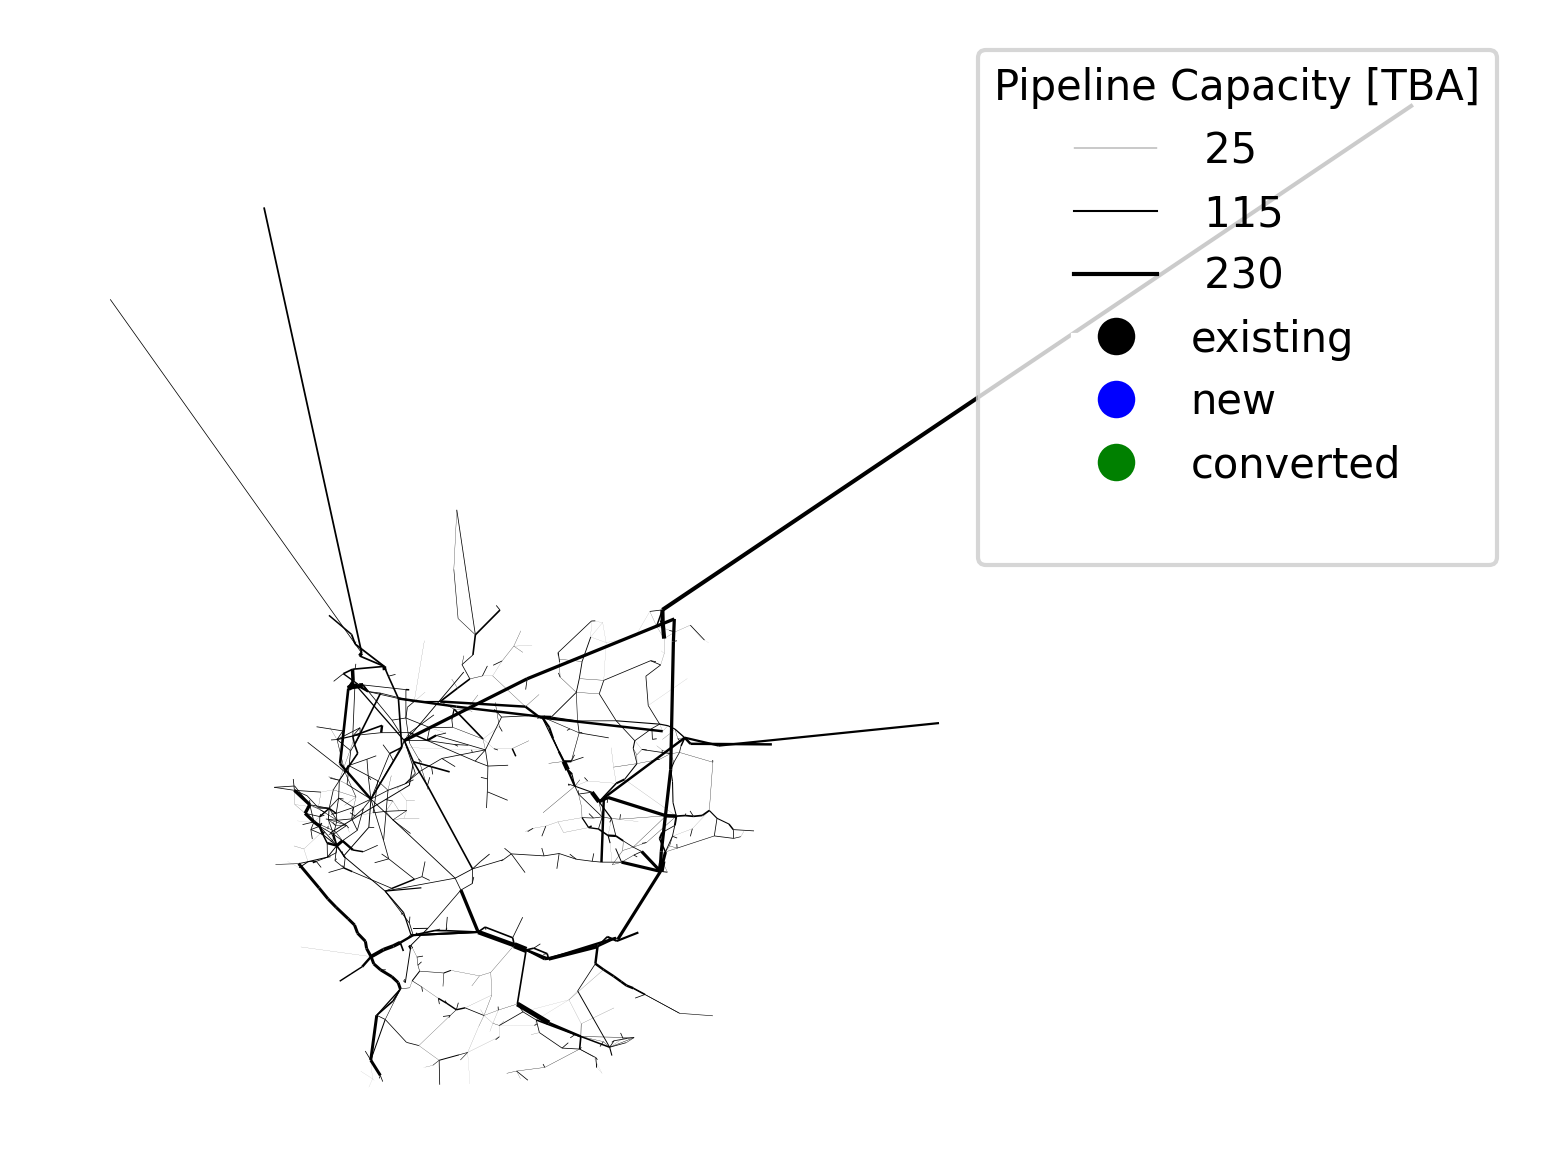

In [37]:
#plot the input network
nodes = unique_nodes['node_name'].tolist()
edges = parallel_edges_capacity_df[['source_name', 'target_name']].to_records(index=False).tolist()
edge_types = parallel_edges_capacity_df['type'].tolist()
edge_capacities = parallel_edges_capacity_df['capacity'].tolist()

# set Web Mercator coordinates
web_mercator_coordinates = unique_nodes.set_index('node_name')['coordinates'].to_dict()

custom_dpi=300
save_path_network = images_folder_path + 'input_network_plot.png'

#plot
plot_large_network(nodes, edges, edge_types, edge_capacities, web_mercator_coordinates, dpi=custom_dpi,
                                 save_fig = save_path_network)

## methane flow plotting

In [30]:
# Extract unique nodes and their coordinates
# Create separate dataframes for source nodes and target nodes
source_nodes = df_flows_methane_merged[['Source', 'source']].drop_duplicates().reset_index(drop=True)
target_nodes = df_flows_methane_merged[['Destination', 'target']].drop_duplicates().reset_index(drop=True)

# Rename columns for clarity
source_nodes.columns = ['node_name', 'coordinates']
target_nodes.columns = ['node_name', 'coordinates']

# Concatenate the two dataframes for the nodes and coordinates dataframe
unique_nodes = pd.concat([source_nodes, target_nodes]).drop_duplicates().reset_index(drop=True)

#create an edges dataframe
edges_original_network_df = df_flows_methane_merged[['Source', 'Destination', 'Flow']]
# Assuming 'df' is your existing data frame

# New column data that all pipes exist
new_column_data = 'existing'

# Specify the index where you want to insert the new column (2 in this example)
index_to_insert = 2

# Use the insert method to add a new column named 'type' at the specified index
edges_original_network_df.insert(index_to_insert, 'type', new_column_data)

#create a dataframe without parallel pipelines but consider the correct capacity
parallel_edges_capacity_df = edges_original_network_df.groupby(['Source', 'Destination','type'])['Flow'].sum().reset_index()

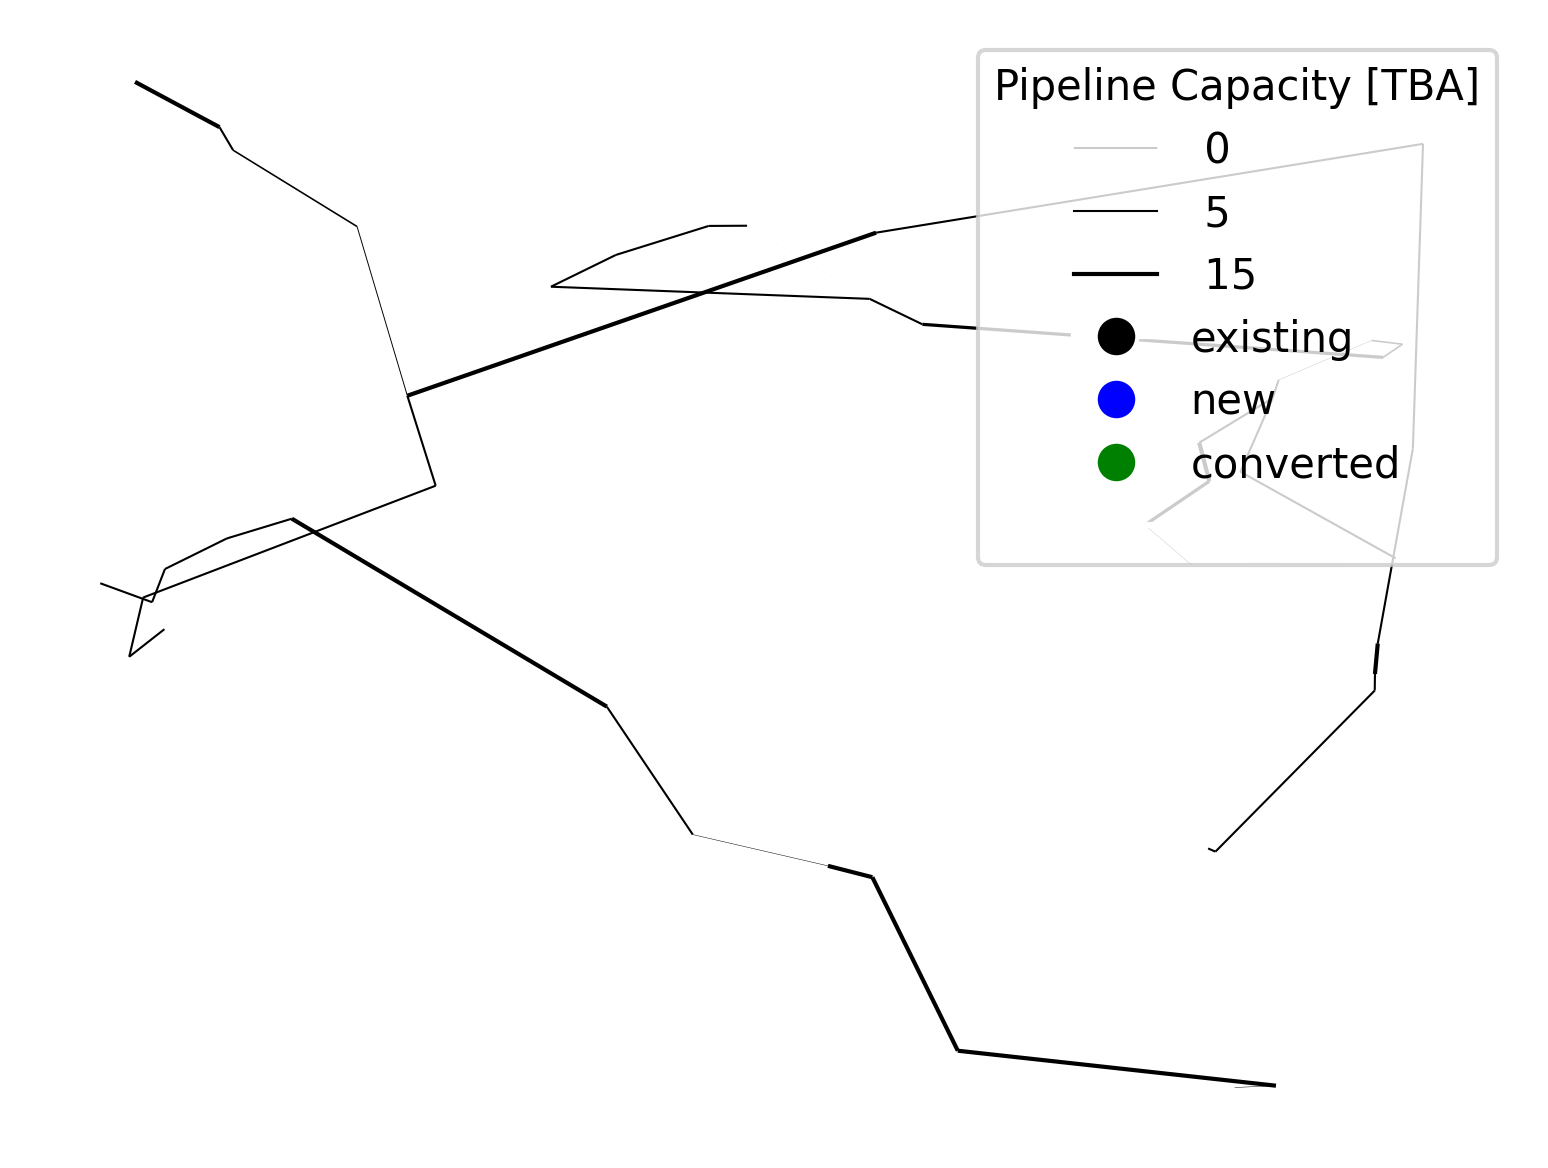

In [34]:
#plot the input network
nodes = unique_nodes['node_name'].tolist()
edges = parallel_edges_capacity_df[['Source', 'Destination']].to_records(index=False).tolist()
edge_types = parallel_edges_capacity_df['type'].tolist()
edge_capacities = parallel_edges_capacity_df['Flow'].tolist()

# set Web Mercator coordinates
web_mercator_coordinates = unique_nodes.set_index('node_name')['coordinates'].to_dict()

custom_dpi=300
save_path_network = images_folder_path + 'methane_network_plot.png'

#plot
plot_large_network(nodes, edges, edge_types, edge_capacities, web_mercator_coordinates, dpi=custom_dpi,
                                 save_fig = save_path_network)

## hydrogen flow plotting

In [43]:
# Extract unique nodes and their coordinates
# Create separate dataframes for source nodes and target nodes
source_nodes = df_flows_hydrogen_merged[['Source', 'source']].drop_duplicates().reset_index(drop=True)
target_nodes = df_flows_hydrogen_merged[['Destination', 'target']].drop_duplicates().reset_index(drop=True)

# Rename columns for clarity
source_nodes.columns = ['node_name', 'coordinates']
target_nodes.columns = ['node_name', 'coordinates']

# Concatenate the two dataframes for the nodes and coordinates dataframe
unique_nodes = pd.concat([source_nodes, target_nodes]).drop_duplicates().reset_index(drop=True)

#create an edges dataframe
edges_original_network_df = df_flows_hydrogen_merged[['Source', 'Destination', 'Flow']]
# Assuming 'df' is your existing data frame

# New column data that all pipes exist
new_column_data = 'existing'

# Specify the index where you want to insert the new column (2 in this example)
index_to_insert = 2

# Use the insert method to add a new column named 'type' at the specified index
edges_original_network_df.insert(index_to_insert, 'type', new_column_data)

#create a dataframe without parallel pipelines but consider the correct capacity
parallel_edges_capacity_df = edges_original_network_df.groupby(['Source', 'Destination','type'])['Flow'].sum().reset_index()

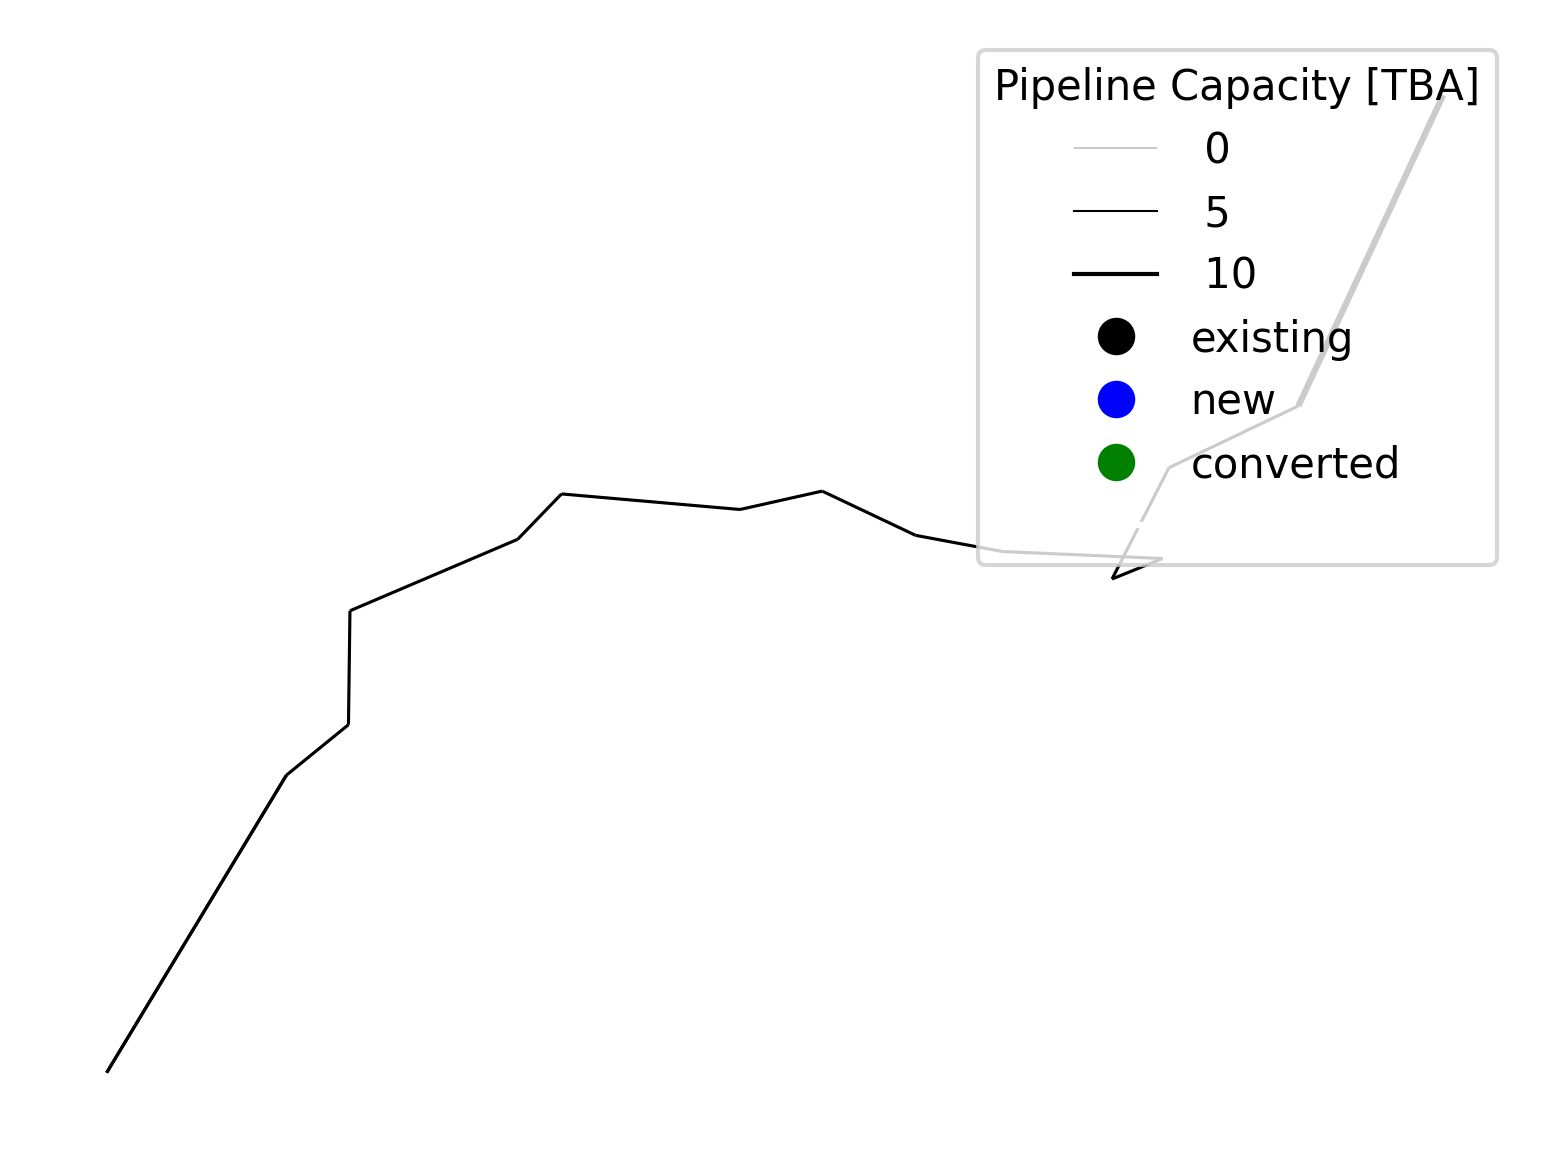

In [44]:
#plot the input network
nodes = unique_nodes['node_name'].tolist()
edges = parallel_edges_capacity_df[['Source', 'Destination']].to_records(index=False).tolist()
edge_types = parallel_edges_capacity_df['type'].tolist()
edge_capacities = parallel_edges_capacity_df['Flow'].tolist()

# set Web Mercator coordinates
web_mercator_coordinates = unique_nodes.set_index('node_name')['coordinates'].to_dict()

custom_dpi=300
save_path_network = images_folder_path + 'hydrogen_network_plot.png'

#plot
plot_large_network(nodes, edges, edge_types, edge_capacities, web_mercator_coordinates, dpi=custom_dpi,
                                 save_fig = save_path_network)